### Notebook 2: Logistic Regression Scorecard

#### Objective
Build a banking-style credit scorecard using:
- WoE binning
- Information Value screening
- Logistic regression
- Score scaling with PDO
- Final scorecard table and applicant scoring

#### Inputs
- Cleaned dataset from Notebook 1: `output/credit_risk_eda_engineered.csv`

#### Outputs
- WoE tables
- IV summary
- Logistic regression model
- Scorecard coefficients
- Applicant score distribution
- Final scored dataset


In [1]:
import os
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, brier_score_loss
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

####  Load data

In [6]:
DATA_PATH = "output/credit_risk_eda_ready.csv"
TARGET_COL = "default_label"

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

(5000, 15)


,age,edu,gender,housing,income,job_occupation,past_bad_credit,married,loan_amount,debt_to_income,credit_history_years,default_label,log_income,log_past_bad_credit,log_loan_amount
0,25,high_school,male,mortgage,38529.33,self_employed,0,0,9178.73,0.73,10.4,0,10.559201,0.0,9.124753
1,59,bachelor,male,rent,NaN,salary_worker,0,0,5594.13,0.26,6.4,0,NaN,0.0,8.629652
2,53,phd,female,rent,12746.85,salary_worker,0,0,3480.77,0.45,2.5,0,9.453118,0.0,8.155296
3,42,master,female,mortgage,39871.71,retired,0,0,8020.42,0.43,4.0,0,10.593447,0.0,8.989871
4,42,high_school,male,own,36575.92,public_sector,0,0,5432.12,0.04,12.6,0,10.507173,0.0,8.600269


### Define modeling data

We separate variables, remove leakage-prone columns, and prepare train/test splits.

In [7]:
drop_cols = [TARGET_COL]

candidate_features = [c for c in df.columns if c not in drop_cols]

# Remove obvious leakage or ID-like fields if present
leakage_like = [c for c in candidate_features if "target" in c.lower() or "label" in c.lower() or "id" in c.lower()]
candidate_features = [c for c in candidate_features if c not in leakage_like]

print("Features used:", candidate_features)
print("Count:", len(candidate_features))

Features used: ['age', 'edu', 'gender', 'housing', 'income', 'job_occupation', 'past_bad_credit', 'married', 'loan_amount', 'debt_to_income', 'credit_history_years', 'log_income', 'log_past_bad_credit', 'log_loan_amount']
Count: 14


In [8]:
X = df[candidate_features].copy()
y = df[TARGET_COL].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train = X_train.copy()
train[TARGET_COL] = y_train.values

test = X_test.copy()
test[TARGET_COL] = y_test.values

print(train.shape, test.shape)

(3500, 15) (1500, 15)


####  WoE binning and IV

This notebook uses a simplified but realistic banking scorecard workflow:
- numeric features are binned by quantiles,
- categorical features are grouped by category,
- WoE is computed from good/bad distributions,
- IV is used to screen variables.

In [10]:
def woe_iv_table(data, feature, target=TARGET_COL, bins=10, min_bin_size=0.05):
    s = data[[feature, target]].copy()
    s = s.dropna(subset=[target])

    if pd.api.types.is_numeric_dtype(s[feature]):
        try:
            s["bin"] = pd.qcut(s[feature], q=min(bins, s[feature].nunique()), duplicates="drop")
        except Exception:
            s["bin"] = s[feature]
    else:
        s["bin"] = s[feature].astype("object").fillna("Missing")

    g = s.groupby("bin", observed=True)[target].agg(["count", "sum"]).reset_index()
    g.columns = ["bin", "count", "bad"]
    g["good"] = g["count"] - g["bad"]

    total_bad = g["bad"].sum()
    total_good = g["good"].sum()

    g["bad_dist"] = g["bad"] / total_bad if total_bad > 0 else 0
    g["good_dist"] = g["good"] / total_good if total_good > 0 else 0

    eps = 1e-6
    g["woe"] = np.log((g["good_dist"] + eps) / (g["bad_dist"] + eps))
    g["iv_bin"] = (g["good_dist"] - g["bad_dist"]) * g["woe"]
    iv = g["iv_bin"].sum()

    return g.sort_values("woe"), iv


def apply_woe_map(data, feature, woe_df):
    s = data[feature].copy()

    if pd.api.types.is_numeric_dtype(s):
        bins = woe_df["bin"].tolist()
        if hasattr(bins[0], "left"):
            out = pd.Series(index=data.index, dtype=float)
            for interval, w in zip(woe_df["bin"], woe_df["woe"]):
                mask = s.between(interval.left, interval.right, inclusive="right")
                out.loc[mask] = w
            return out.fillna(0.0)
        else:
            return s.map(woe_df.set_index("bin")["woe"]).fillna(0.0)
    else:
        temp = s.astype("object").fillna("Missing")
        return temp.map(woe_df.set_index("bin")["woe"]).fillna(0.0)

In [11]:
woe_tables = {}
iv_rows = []

for col in candidate_features:
    tbl, iv = woe_iv_table(train, col, target=TARGET_COL, bins=10)
    woe_tables[col] = tbl
    iv_rows.append([col, iv])

iv_df = pd.DataFrame(iv_rows, columns=["feature", "iv"]).sort_values("iv", ascending=False)
display(iv_df)

iv_df.to_csv("output/iv_summary.csv", index=False)

,feature,iv
9,debt_to_income,0.142476
8,loan_amount,0.125175
13,log_loan_amount,0.125175
10,credit_history_years,0.122675
4,income,0.047601
11,log_income,0.047601
1,edu,0.030275
0,age,0.022833
5,job_occupation,0.022506
2,gender,0.008337


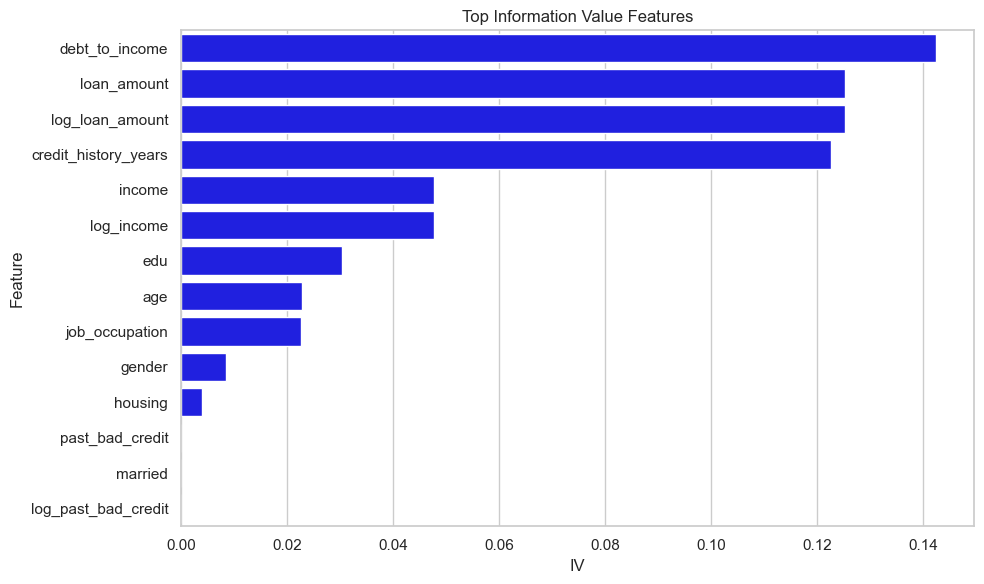

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=iv_df.head(20), x="iv", y="feature", color="blue")
plt.title("Top Information Value Features")
plt.xlabel("IV")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("output/iv_top_features.png")
plt.show()

### Select variables

A typical banking scorecard uses a small number of stable, interpretable features.  
Here we keep features above a modest IV threshold.

In [14]:
### feature selection
selected_features = iv_df.loc[iv_df["iv"] >= 0.02, "feature"].tolist()
print("Selected features:", selected_features)
print("Count:", len(selected_features))

if len(selected_features) == 0:
    selected_features = iv_df.head(8)["feature"].tolist()

Selected features: ['debt_to_income', 'loan_amount', 'log_loan_amount', 'credit_history_years', 'income', 'log_income', 'edu', 'age', 'job_occupation']
Count: 9


##### Transform variables to WoE

We convert the selected predictors into WoE space so that logistic regression behaves like a traditional scorecard model.

In [15]:
X_train_woe = pd.DataFrame(index=X_train.index)
X_test_woe = pd.DataFrame(index=X_test.index)

for col in selected_features:
    tbl = woe_tables[col].copy()
    X_train_woe[col] = apply_woe_map(X_train, col, tbl)
    X_test_woe[col] = apply_woe_map(X_test, col, tbl)

X_train_woe = X_train_woe.fillna(0.0)
X_test_woe = X_test_woe.fillna(0.0)

display(X_train_woe.head())

,debt_to_income,loan_amount,log_loan_amount,credit_history_years,income,log_income,edu,age,job_occupation
1228,-0.529877,0.292193,0.292193,-0.171282,0.198433,0.198433,-0.028942,-0.085756,-0.096043
1712,0.157154,-0.240383,-0.240383,-0.351343,-0.015015,-0.015015,-0.028942,-0.018286,0.083740
94,0.006203,0.232028,0.232028,-0.351343,-0.347933,-0.347933,-0.078562,-0.018286,0.083740
1481,0.157154,0.655398,0.655398,-0.058726,0.258760,0.258760,-0.028942,-0.070825,0.187834
4264,0.262792,0.292193,0.292193,0.412470,-0.015015,-0.015015,-0.078562,0.232028,-0.096043


#### Fit logistic regression

This is the core of the scorecard.  
Coefficients on WoE variables are directly compatible with points scaling.

In [30]:
lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X_train_woe, y_train)

train_pred = lr.predict_proba(X_train_woe)[:, 1]
test_pred = lr.predict_proba(X_test_woe)[:, 1]

print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC:", roc_auc_score(y_test, test_pred))

coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df)
coef_df.to_csv("output/logistic_coefficients.csv", index=False)

Train AUC: 0.6952293738008024
Test AUC: 0.5500244836182336


,feature,coefficient
4,income,-0.467286
5,log_income,-0.480855
1,loan_amount,-0.482902
2,log_loan_amount,-0.494705
7,age,-0.810043
8,job_occupation,-0.821801
6,edu,-0.911619
3,credit_history_years,-0.934788
0,debt_to_income,-1.004145


In [31]:
threshold = 0.5
test_label = (test_pred >= threshold).astype(int)

print(classification_report(y_test, test_label, zero_division=0))
print("Brier score:", brier_score_loss(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1404
           1       0.00      0.00      0.00        96

    accuracy                           0.94      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.88      0.94      0.91      1500

Brier score: 0.06084346396329863


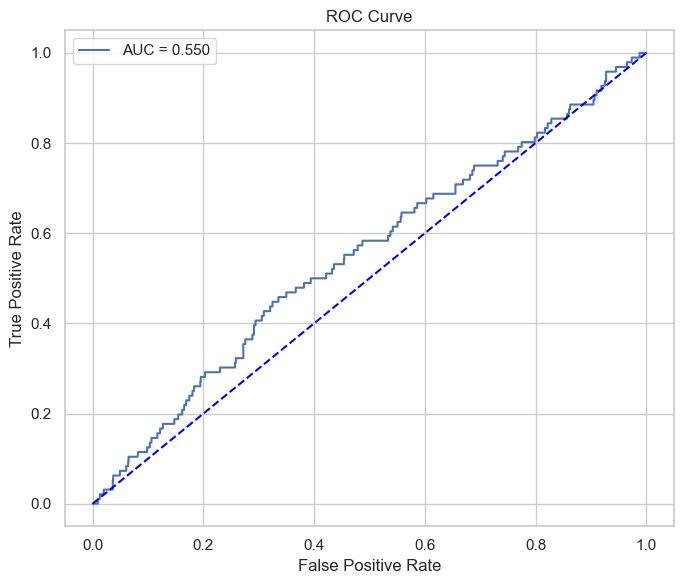

In [32]:
fpr, tpr, _ = roc_curve(y_test, test_pred)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_pred):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="blue")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("output/roc_curve.png")
plt.show()

#### Calibration

A banking scorecard must be not only discriminative but also reasonably calibrated.

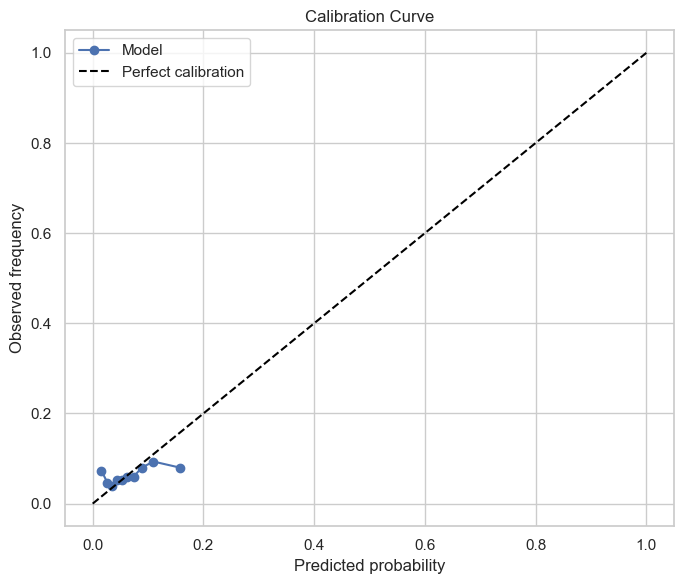

In [33]:
prob_true, prob_pred = calibration_curve(y_test, test_pred, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("output/calibration_curve.png")
plt.show()

#### Convert probabilities to score

We use a standard scorecard scaling:
- Base score = 600
- Base odds = 50:1
- PDO = 20

This means 20 points correspond to a doubling of odds, which is a common industry convention [web:60][web:64].

In [34]:
PDO = 20
base_score = 600
base_odds = 50

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

def prob_to_score(p):
    odds = (1 - p) / np.clip(p, 1e-9, 1 - 1e-9)
    return offset + factor * np.log(odds)

train_score = prob_to_score(train_pred)
test_score = prob_to_score(test_pred)

print("Score factor:", factor)
print("Score offset:", offset)
print("Train score range:", (train_score.min(), train_score.max()))
print("Test score range:", (test_score.min(), test_score.max()))

Score factor: 28.85390081777927
Score offset: 487.1228762045055
Train score range: (512.1931526314129, 654.9650458155393)
Test score range: (516.3534852979092, 654.309899464946)


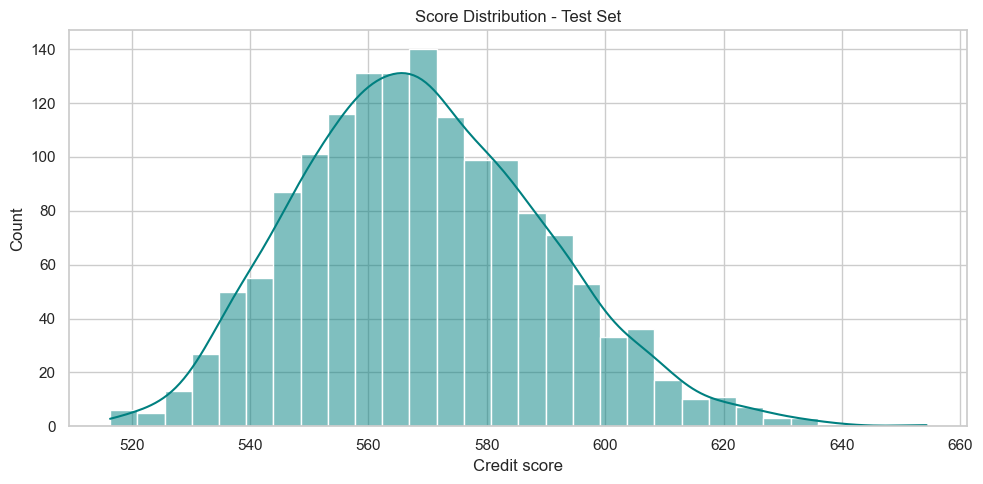

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(test_score, bins=30, kde=True, color="teal")
plt.title("Score Distribution - Test Set")
plt.xlabel("Credit score")
plt.tight_layout()
plt.savefig("output/score_distribution.png")
plt.show()

#### Build the scorecard table

Each feature contributes points based on WoE values and the fitted logistic coefficients.

In [36]:
scorecard_rows = []

for col in selected_features:
    tbl = woe_tables[col].copy()
    beta = coef_df.loc[coef_df["feature"] == col, "coefficient"].values[0]
    tbl["feature"] = col
    tbl["beta"] = beta
    tbl["points"] = -factor * beta * tbl["woe"]
    scorecard_rows.append(tbl[["feature", "bin", "count", "bad", "good", "woe", "iv_bin", "beta", "points"]])

scorecard = pd.concat(scorecard_rows, ignore_index=True)
display(scorecard.head(30))
scorecard.to_csv("output/scorecard_table.csv", index=False)

,feature,bin,count,bad,good,woe,iv_bin,beta,points
0,debt_to_income,"(0.56, 1.08]",316,33,283,-0.532700,0.033000,-1.004145,-15.434190
1,debt_to_income,"(0.43, 0.49]",336,35,301,-0.529877,0.034674,-1.004145,-15.352410
2,debt_to_income,"(0.38, 0.43]",343,28,315,-0.261274,0.007646,-1.004145,-7.570012
3,debt_to_income,"(0.19, 0.24]",314,20,294,0.006203,0.000004,-1.004145,0.179735
4,debt_to_income,"(0.49, 0.56]",325,19,306,0.097501,0.000862,-1.004145,2.824948
5,debt_to_income,"(0.24, 0.29]",380,21,359,0.157154,0.002553,-1.004145,4.553316
6,debt_to_income,"(0.33, 0.38]",373,20,353,0.189090,0.003578,-1.004145,5.478598
7,debt_to_income,"(0.29, 0.33]",320,16,304,0.262792,0.005744,-1.004145,7.614002
8,debt_to_income,"(0.009000000000000001, 0.11]",350,16,334,0.356904,0.011133,-1.004145,10.340767
9,debt_to_income,"(0.11, 0.19]",377,12,365,0.733337,0.043282,-1.004145,21.247355


#### final applicant score

In [37]:
def score_applicants(data, selected_features, woe_tables, lr_model):
    Xw = pd.DataFrame(index=data.index)
    for col in selected_features:
        Xw[col] = apply_woe_map(data, col, woe_tables[col]).fillna(0.0)
    p = lr_model.predict_proba(Xw)[:, 1]
    s = prob_to_score(p)
    out = data.copy()
    out["pred_default_prob"] = p
    out["credit_score"] = s
    return out

scored_test = score_applicants(X_test, selected_features, woe_tables, lr)
display(scored_test.head())
scored_test.to_csv("output/scored_test_set.csv", index=False)

,age,edu,gender,housing,income,job_occupation,past_bad_credit,married,loan_amount,debt_to_income,credit_history_years,log_income,log_past_bad_credit,log_loan_amount,pred_default_prob,credit_score
3359,47,high_school,male,mortgage,38526.09,student,0,1,7210.61,0.20,5.4,10.559117,0.0,8.883448,0.106577,548.471710
34,65,phd,female,rent,19351.46,self_employed,0,1,19728.01,0.45,9.4,9.870575,0.0,9.889845,0.132012,541.463058
3721,50,high_school,male,own,15816.72,retired,0,1,3385.87,0.38,5.5,9.668886,0.0,8.127661,0.059158,566.949029
1645,35,high_school,male,mortgage,19871.39,self_employed,0,0,4374.68,0.53,9.8,9.897087,0.0,8.383817,0.012156,614.013364
4772,29,high_school,female,own,37563.55,public_sector,0,0,16910.53,0.43,8.5,10.533816,0.0,9.735751,0.134173,540.922656


#### Suggested cutoff analysis

In a real bank, the cutoff is chosen using business cost, approval rate, and risk appetite, not only a 0.5 probability threshold.

In [38]:
cutoffs = pd.DataFrame({
    "threshold_prob": [0.2, 0.3, 0.4, 0.5],
})

cutoffs["equivalent_score"] = prob_to_score(cutoffs["threshold_prob"])
display(cutoffs)
cutoffs.to_csv("output/cutoff_table.csv", index=False)

,threshold_prob,equivalent_score
0,0.2,527.122876
1,0.3,511.570725
2,0.4,498.822126
3,0.5,487.122876
